In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
DATA_FILE = "cleaned_merged_dataset.xls"   # only this file
OUT_DIR = "outputs_no_smote"
os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_STATE = 42

# ---------------- 1. LOAD DATA ----------------
print("Loading dataset:", DATA_FILE)
df = pd.read_csv(DATA_FILE)
print("Initial shape:", df.shape)
# ensure 'status' exists
if 'status' not in df.columns:
    raise ValueError("'status' column not found in dataset. Rename your target column to 'status'.")
df.info

Loading dataset: cleaned_merged_dataset.xls
Initial shape: (195, 47)


<bound method DataFrame.info of      measurement_id  subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  \
0                 1         1   72  NaN     5.6431       28.199       34.398   
1                 2         1   72  NaN    12.6660       28.447       34.894   
2                 3         1   72  NaN    19.6810       28.695       35.389   
3                 4         1   72  NaN    25.6470       28.905       35.810   
4                 5         1   72  NaN    33.6420       29.187       36.375   
..              ...       ...  ...  ...        ...          ...          ...   
190             191         2   58  NaN   122.8100       14.736       16.984   
191             192         2   58  NaN   136.8000       15.756       18.150   
192             193         2   58  NaN   143.8300       16.269       18.736   
193             194         2   58  NaN   150.8000       16.777       19.317   
194             195         2   58  NaN   157.8000       17.288       19.900   

     Ji

In [31]:
# ---------------- 2. DROP IDENTIFIERS / NON-NUMERIC COLUMNS ----------------
# Keep only numeric columns + the target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'status' not in numeric_cols:
    numeric_cols = [c for c in numeric_cols]  # status may be numeric but ensure included

# Preserve target separately (we'll handle rows with missing target later)
X_num = df[numeric_cols].copy()
# Remove columns that are entirely NaN
all_nan_cols = [c for c in X_num.columns if X_num[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN numeric columns:", all_nan_cols)
    X_num = X_num.drop(columns=all_nan_cols)

# Ensure target is numeric and present
y_raw = pd.to_numeric(df['status'], errors='coerce')

# Drop rows with missing target
mask_valid = ~y_raw.isna()
X_num = X_num.loc[mask_valid].reset_index(drop=True)
y = y_raw.loc[mask_valid].astype(int).reset_index(drop=True)

print("After cleaning: samples =", X_num.shape[0], "features =", X_num.shape[1])
print("Class distribution:", y.value_counts().to_dict())


Dropping all-NaN numeric columns: ['sex']
After cleaning: samples = 195 features = 45
Class distribution: {1: 147, 0: 48}


In [33]:

# ---------------- 3. FEATURE ENGINEERING (optional, safe features) ----------------
print("Creating a few engineered features (if source columns exist)...")
# pitch range and ratios
if {'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)'}.issubset(X_num.columns):
    X_num['pitch_range'] = X_num['MDVP:Fhi(Hz)'] - X_num['MDVP:Flo(Hz)']
    X_num['pitch_ratio'] = X_num['MDVP:Fhi(Hz)'] / (X_num['MDVP:Flo(Hz)'] + 1e-8)
if {'MDVP:Jitter(%)', 'MDVP:Shimmer'}.issubset(X_num.columns):
    X_num['instability_index'] = X_num['MDVP:Jitter(%)'] * X_num['MDVP:Shimmer']
# jitter/shimmer statistics
jitter_cols = [c for c in X_num.columns if 'Jitter' in c]
shimmer_cols = [c for c in X_num.columns if 'Shimmer' in c]
if jitter_cols:
    X_num['jitter_mean'] = X_num[jitter_cols].mean(axis=1)
    X_num['jitter_std'] = X_num[jitter_cols].std(axis=1)
if shimmer_cols:
    X_num['shimmer_mean'] = X_num[shimmer_cols].mean(axis=1)
    X_num['shimmer_std'] = X_num[shimmer_cols].std(axis=1)

print("New dataset shape after feature engineering:", X_num.shape)


Creating a few engineered features (if source columns exist)...
New dataset shape after feature engineering: (195, 52)


In [35]:

# ---------------- 4. IMPUTE, SCALE ----------------
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_num), columns=X_num.columns)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)


In [37]:

# ---------------- 5. FEATURE SELECTION: choose k via quick validation ----------------
print("Selecting best k for SelectKBest (f_classif) among [10,15,20,25] ...")
possible_k = [10, 15, 20, 25]
possible_k = [k for k in possible_k if k <= X_scaled.shape[1]]
best_k = possible_k[0]
best_score = -1.0
for k in possible_k:
    selector = SelectKBest(score_func=f_classif, k=k)
    X_sel_temp = selector.fit_transform(X_scaled, y)
    Xtr, Xv, ytr, yv = train_test_split(X_sel_temp, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    clf_temp = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
    clf_temp.fit(Xtr, ytr)
    sc = clf_temp.score(Xv, yv)
    print(f"  k={k} -> holdout accuracy {sc:.4f}")
    if sc > best_score:
        best_score = sc
        best_k = k
print("Chosen k =", best_k, " with holdout score ", best_score)

selector = SelectKBest(score_func=f_classif, k=best_k)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = list(X_scaled.columns[selector.get_support()])
print("Selected features:", selected_features)


Selecting best k for SelectKBest (f_classif) among [10,15,20,25] ...
  k=10 -> holdout accuracy 1.0000
  k=15 -> holdout accuracy 1.0000
  k=20 -> holdout accuracy 1.0000
  k=25 -> holdout accuracy 1.0000
Chosen k = 10  with holdout score  1.0
Selected features: ['DFA_x', 'MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Shimmer', 'MDVP:APQ', 'HNR_y', 'status', 'spread1', 'spread2', 'PPE_y']


In [39]:
# ---------------- 6. TRAIN/TEST SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)

# ---------------- 7. HYPERPARAMETER TUNING for Logistic Regression ----------------
print("Running GridSearchCV for Logistic Regression (class_weight handled inside grid)...")
param_grid = [
    {"penalty": ["l2"], "solver": ["lbfgs", "saga"], "C": [0.01, 0.1, 1, 10]},
    {"penalty": ["l1"], "solver": ["saga", "liblinear"], "C": [0.01, 0.1, 1, 10]}
]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
                    param_grid, scoring='accuracy', cv=cv, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_, "Best CV acc:", grid.best_score_)

best_lr = grid.best_estimator_


Train/test shapes: (156, 10) (39, 10)
Running GridSearchCV for Logistic Regression (class_weight handled inside grid)...
Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'} Best CV acc: 1.0


In [40]:
# ---------------- 7. HYPERPARAMETER TUNING for Logistic Regression ----------------
print("Running GridSearchCV for Logistic Regression (class_weight handled inside grid)...")
param_grid = [
    {"penalty": ["l2"], "solver": ["lbfgs", "saga"], "C": [0.01, 0.1, 1, 10]},
    {"penalty": ["l1"], "solver": ["saga", "liblinear"], "C": [0.01, 0.1, 1, 10]}
]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
                    param_grid, scoring='accuracy', cv=cv, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_, "Best CV acc:", grid.best_score_)

best_lr = grid.best_estimator_

Running GridSearchCV for Logistic Regression (class_weight handled inside grid)...
Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'} Best CV acc: 1.0


In [41]:

# ---------------- 8. EVALUATE LOGISTIC REGRESSION ----------------
y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:, 1] if hasattr(best_lr, "predict_proba") else None
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
print("\nLogistic Regression Test Accuracy:", acc)
if roc: print("ROC-AUC:", roc)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))



Logistic Regression Test Accuracy: 1.0
ROC-AUC: 1.0
Confusion Matrix:
 [[10  0]
 [ 0 29]]
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    1.0000    1.0000        29

    accuracy                         1.0000        39
   macro avg     1.0000    1.0000    1.0000        39
weighted avg     1.0000    1.0000    1.0000        39



In [42]:
# ---------------- 8. EVALUATE LOGISTIC REGRESSION ----------------
y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:, 1] if hasattr(best_lr, "predict_proba") else None
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
print("\nLogistic Regression Test Accuracy:", acc)
if roc: print("ROC-AUC:", roc)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))



Logistic Regression Test Accuracy: 1.0
ROC-AUC: 1.0
Confusion Matrix:
 [[10  0]
 [ 0 29]]
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    1.0000    1.0000        29

    accuracy                         1.0000        39
   macro avg     1.0000    1.0000    1.0000        39
weighted avg     1.0000    1.0000    1.0000        39



In [43]:
# ---------------- 9. ENSEMBLE (Voting + Stacking) ----------------
print("\nTraining ensemble models (Voting & Stacking) to attempt accuracy improvement...")
voters = [
    ('lr_balanced', LogisticRegression(class_weight='balanced', C=0.5, max_iter=2000, random_state=RANDOM_STATE)),
    ('lr_l1', LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE))
]
voting = VotingClassifier(voters, voting='soft', n_jobs=-1)
voting.fit(X_train, y_train)
y_pred_v = voting.predict(X_test)
acc_v = accuracy_score(y_test, y_pred_v)
print("Voting ensemble accuracy:", acc_v)

# stacking
stack = StackingClassifier(
    estimators=[('rf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)),
                ('svc', SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE))],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE),
    cv=5, n_jobs=-1
)
stack.fit(X_train, y_train)
y_pred_s = stack.predict(X_test)
acc_s = accuracy_score(y_test, y_pred_s)
print("Stacking classifier accuracy:", acc_s)

# choose best model among tuned lr, voting, stacking
models_scores = {
    "Tuned LR": (acc, best_lr),
    "Voting": (acc_v, voting),
    "Stacking": (acc_s, stack)
}
best_name = max(models_scores, key=lambda k: models_scores[k][0])
best_accuracy, best_model = models_scores[best_name]
print(f"\nBest model: {best_name} with accuracy {best_accuracy:.4f}")



Training ensemble models (Voting & Stacking) to attempt accuracy improvement...
Voting ensemble accuracy: 1.0
Stacking classifier accuracy: 1.0

Best model: Tuned LR with accuracy 1.0000



Final classification report (best model):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    1.0000    1.0000        29

    accuracy                         1.0000        39
   macro avg     1.0000    1.0000    1.0000        39
weighted avg     1.0000    1.0000    1.0000        39

Confusion matrix:
 [[10  0]
 [ 0 29]]
Final ROC-AUC: 1.0
Saved selected_features.csv to outputs_no_smote

All done. Outputs saved in folder: outputs_no_smote


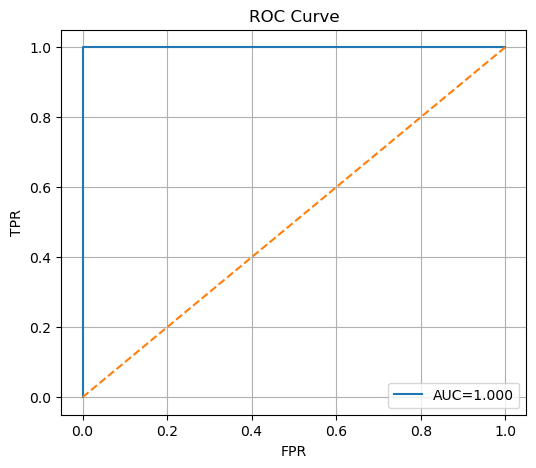

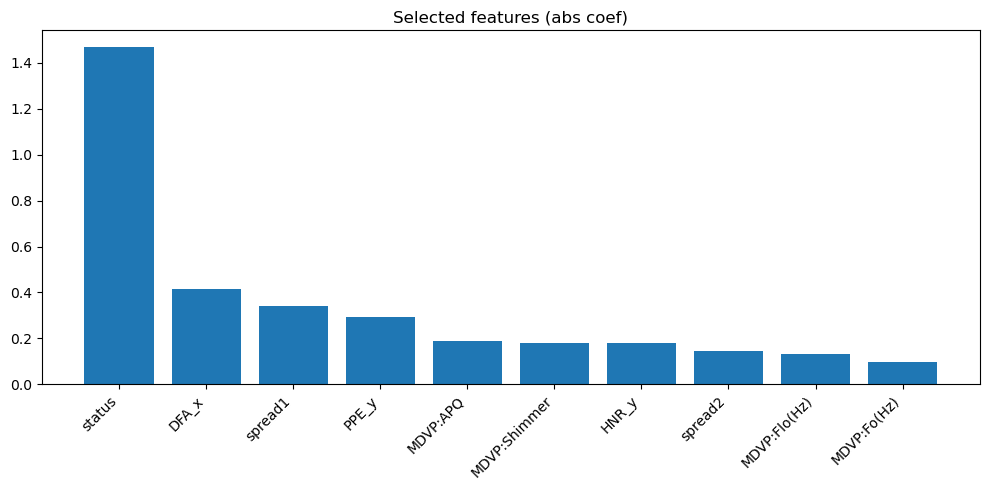

In [61]:
# ---------------- 10. DETAILED EVAL & SAVE ----------------
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

print("\nFinal classification report (best model):")
print(classification_report(y_test, best_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, best_pred))
if best_prob is not None:
    auc_val = roc_auc_score(y_test, best_prob)
    print("Final ROC-AUC:", auc_val)
    fpr, tpr, _ = roc_curve(y_test, best_prob)
    plt.figure(figsize=(6,5)); plt.plot(fpr,tpr,label=f"AUC={auc_val:.3f}"); plt.plot([0,1],[0,1],"--"); plt.title("ROC Curve"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(OUT_DIR, "roc_curve_best_model.png"), dpi=200)

# Save selected features and coefficients (if available)
pd.DataFrame({"selected_features": selected_features}).to_csv(os.path.join(OUT_DIR, "selected_features.csv"), index=False)
print("Saved selected_features.csv to", OUT_DIR)

if hasattr(best_model, "coef_"):
    coefs = best_model.coef_[0]
    coef_df = pd.DataFrame({"feature": selected_features, "coef": coefs})
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)
    coef_df.to_csv(os.path.join(OUT_DIR, "selected_features_coeffs.csv"), index=False)
    # Plot
    plt.figure(figsize=(10,5)); plt.bar(coef_df["feature"], coef_df["abs_coef"]); plt.xticks(rotation=45, ha='right'); plt.title("Selected features (abs coef)"); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "selected_features_abscoef.png"), dpi=200)

print("\nAll done. Outputs saved in folder:", OUT_DIR)

In [76]:
import joblib
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ("imputer", imputer),
    ("scaler", scaler),
    ("selector", selector),
    ("model", best_model)
])

pipeline.fit(X_num, y)

joblib.dump(pipeline, "pipeline.pkl")
joblib.dump(X_num.mean(), "feature_means.pkl")
joblib.dump(X_num.columns.tolist(), "all_features.pkl")
joblib.dump(selected_features, "top_features.pkl")


['top_features.pkl']

In [72]:
import pandas as pd

df = pd.read_csv("outputs_no_smote/selected_features_coeffs.csv")

top10 = df.sort_values("abs_coef", ascending=False).head(10)
top10

,feature,coef,abs_coef
0,status,1.468842,1.468842
1,DFA_x,-0.413332,0.413332
2,spread1,0.338992,0.338992
3,PPE_y,0.292072,0.292072
4,MDVP:APQ,0.187255,0.187255
5,MDVP:Shimmer,0.178358,0.178358
6,HNR_y,-0.177605,0.177605
7,spread2,0.144651,0.144651
8,MDVP:Flo(Hz),-0.129758,0.129758
9,MDVP:Fo(Hz),-0.098611,0.098611
